## Project #4 -  Interpret
### Import packages and data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from IPython.display import display

In [19]:
##Install any needed pacakages with the following code, then comment the code out
#import sys
#!{sys.executable} -m pip install seaborn

### Install GeoPandas
For this project we will be using the `GeoPandas` package to help us map our NRI Risk Data.  In the space below, let's install `GeoPands`.

In [2]:
#import sys
#!{sys.executable} -m pip install geopandas

##Import
import geopandas as gpd

'{sys.executable}' is not recognized as an internal or external command,
operable program or batch file.


ModuleNotFoundError: No module named 'geopandas'

#### Load in the data for Project #4
First, let's refresh our memories and load in all of the data needed for this project.  There are  two CSV documents you need to download from Canvas and read into Python.  Load in your Household_data and Vehicle Data below.

In [8]:
#### Load in each CSV
all_tracts = pd.read_csv("NRI_Table_CensusTracts.csv")
co_nri = all_tracts[all_tracts["STATE"] == "Colorado"]
co_svi = pd.read_csv("Colorado.csv")
nri_dictionary = pd.read_csv("NRIDataDictionary.csv")

#print(ne_nri)
#print(nri_dictionary)
#print(ne_svi)

#### Lab Activity #1
Show you have imported a state data set other than Nebraska.  Print out a feature of this dataset using one of our data checking methods to show you have correctly loaded the data.

In [9]:
#### Student import in space below
co_nri.head(1)

,OID_,NRI_ID,STATE,STATEABBRV,STATEFIPS,COUNTY,COUNTYTYPE,COUNTYFIPS,STCOFIPS,TRACT,...,WNTW_EALS,WNTW_EALR,WNTW_ALRB,WNTW_ALRP,WNTW_ALRA,WNTW_ALR_NPCTL,WNTW_RISKV,WNTW_RISKS,WNTW_RISKR,NRI_VER
13306,13307,T08001007801,Colorado,CO,8,Adams,County,1,8001,7801,...,80.622043,Relatively High,0.000004,1.401850e-07,0.0,66.299513,15253.695689,87.580586,Relatively High,December 2025


In [10]:
co_svi.head(1)

,ST,STATE,ST_ABBR,STCNTY,COUNTY,FIPS,LOCATION,AREA_SQMI,E_TOTPOP,M_TOTPOP,...,EP_ASIAN,MP_ASIAN,EP_AIAN,MP_AIAN,EP_NHPI,MP_NHPI,EP_TWOMORE,MP_TWOMORE,EP_OTHERRACE,MP_OTHERRACE
0,8,Colorado,CO,8001,Adams County,8001007801,Census Tract 78.01; Adams County; Colorado,0.247698,3889,641,...,26.3,10.5,1.0,0.9,0.2,1.6,0.0,1.0,0.0,1.0


## Joining Datasets

Next, wouldn't it be nice if all this data was in one dataframe instead of 2?  We can create one big DataFrame in Python by using the `merge()` command.  `merge()` does something to the data that we call "joining" in the data science world.  Basically, you take two data files and join them using a "key" that each dataframe has in common.  If we look at our data CSVs, both CSVs have a unique code related to the city, county and FIPS number.  In the Census Tract data it is "STCOFIPS" and in the SVI data it is "STCNTY". 

Therefore our first step will be to make sure each dataframe has the same column name to merge on. 
 Then we can complete the merge.


In [13]:
### Create a column in Census Tract called "STCNTY"
co_nri['STCNTY'] = co_nri['STCOFIPS']
co_nri.columns

C:\Users\willm\AppData\Local\Temp\ipykernel_21944\3006453027.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  co_nri['STCNTY'] = co_nri['STCOFIPS']


Index(['OID_', 'NRI_ID', 'STATE', 'STATEABBRV', 'STATEFIPS', 'COUNTY',
       'COUNTYTYPE', 'COUNTYFIPS', 'STCOFIPS', 'TRACT',
       ...
       'WNTW_EALR', 'WNTW_ALRB', 'WNTW_ALRP', 'WNTW_ALRA', 'WNTW_ALR_NPCTL',
       'WNTW_RISKV', 'WNTW_RISKS', 'WNTW_RISKR', 'NRI_VER', 'STCNTY'],
      dtype='object', length=468)

Now, each dataframe has a column with a unique identifier that can be used for the join.  We can only join two dataframes at a time and there are a couple different modes for merging.

Check out this link to see more information: https://www.datacamp.com/tutorial/joining-dataframes-pandas 

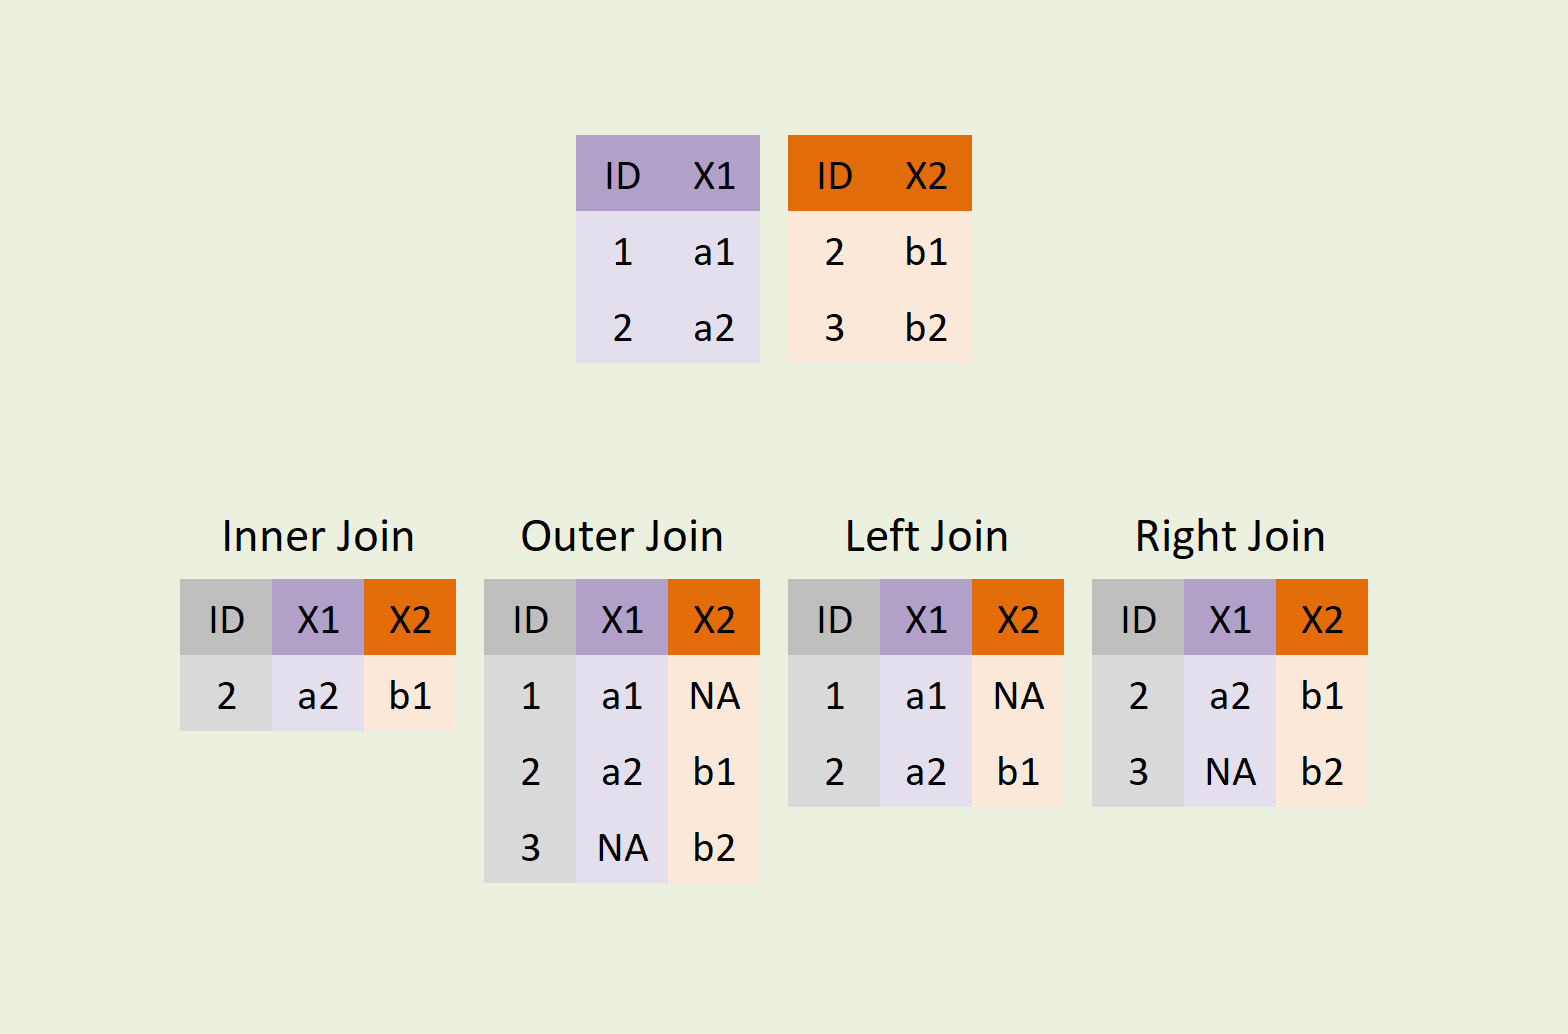

In [30]:
##The following images shows the different ways we can join data
join_png = Image.open('join_types.png')
display(join_png)

In [14]:
##Let's use merge to join our data
complete_data = pd.merge(co_nri, co_svi, on = 'STCNTY')


Once you've joined your data, take a look at the columns.  How many do you now have?

In [15]:
complete_data.columns

Index(['OID_', 'NRI_ID', 'STATE_x', 'STATEABBRV', 'STATEFIPS', 'COUNTY_x',
       'COUNTYTYPE', 'COUNTYFIPS', 'STCOFIPS', 'TRACT',
       ...
       'EP_ASIAN', 'MP_ASIAN', 'EP_AIAN', 'MP_AIAN', 'EP_NHPI', 'MP_NHPI',
       'EP_TWOMORE', 'MP_TWOMORE', 'EP_OTHERRACE', 'MP_OTHERRACE'],
      dtype='object', length=625)

#### Lab Activity #2
Show you can correctly merge your state NRI data with your state SVI data

In [16]:
## Student merge of NRI and SVI data for state other than Nebraska

co_nri['STCNTY'] = co_nri['STCOFIPS']
co_nri.columns
complete_data = pd.merge(co_nri, co_svi, on = 'STCNTY')
complete_data.columns

C:\Users\willm\AppData\Local\Temp\ipykernel_21944\4276735013.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  co_nri['STCNTY'] = co_nri['STCOFIPS']


Index(['OID_', 'NRI_ID', 'STATE_x', 'STATEABBRV', 'STATEFIPS', 'COUNTY_x',
       'COUNTYTYPE', 'COUNTYFIPS', 'STCOFIPS', 'TRACT',
       ...
       'EP_ASIAN', 'MP_ASIAN', 'EP_AIAN', 'MP_AIAN', 'EP_NHPI', 'MP_NHPI',
       'EP_TWOMORE', 'MP_TWOMORE', 'EP_OTHERRACE', 'MP_OTHERRACE'],
      dtype='object', length=625)

Wait a minute, why do we now have `STATE_x` and `STATE_y`?  this is because we merged everything in the data and Python said, well since you have two `STATE` columns and you didn't tell me to do anything special with them, I'm going to name them x and y so you don't get mad at me for dropping data.  So now from this complete data set, we either have to call `STATE_x` or `STATE_y`.  There's nothing wrong with this, you just have to make sure you understand that when you have duplicate columns, you'll have to be careful about calling specific names.

Alternatively, we can try different types of merges.  `merge()` has different forms and arguments that we can use to get rid of duplicates.  We can use the `suffixes` argument of the `merge()` function to tell Python, only keep the columns from the `right` dataframe.  When we merge, the we have a "right" dataframe and a "left" dataframe.

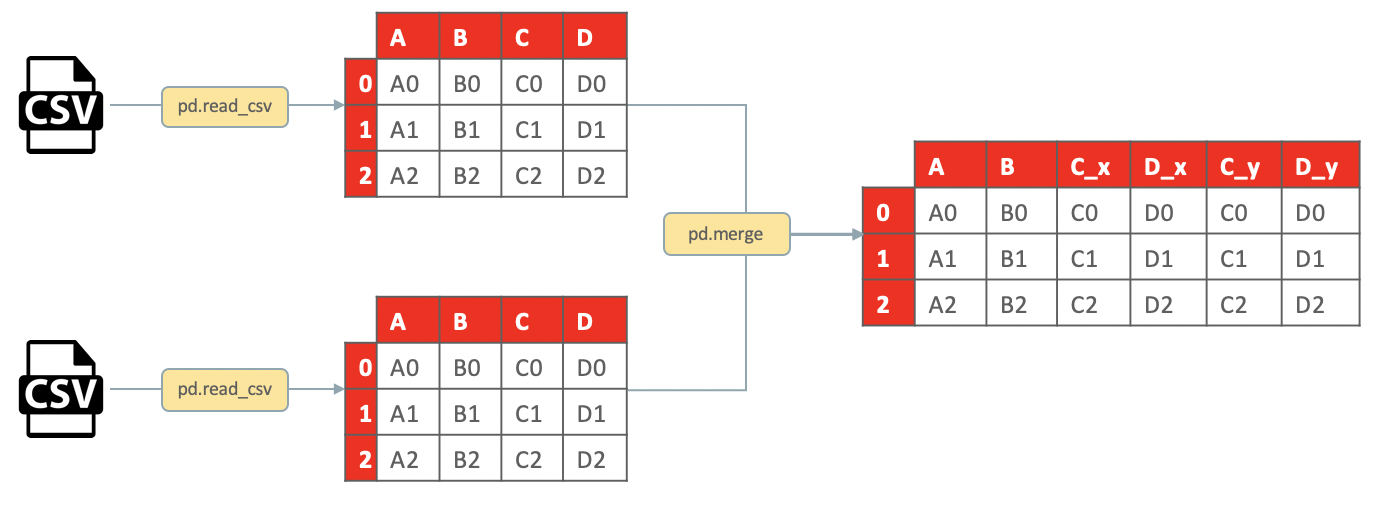

In [29]:
##This figure shows how pandas will merge two datasets if you don't supply any additional arguments to the merge function
merge_png2 = Image.open('flow_pandas_merge.png')
display(merge_png2)

Let's try to fix this `merge()` and remove extra rows.  We can use the `suffixes` argument of the `merge()` function.  The text below will remove the suffix the first time it sees a column like `STATE` and add `_right` the second time it sees `STATE`.

In [17]:
### Merge without repeat column names
complete_data = pd.merge(co_nri, co_svi, on = 'STCNTY', suffixes=('', '_right'))
complete_data.columns

Index(['OID_', 'NRI_ID', 'STATE', 'STATEABBRV', 'STATEFIPS', 'COUNTY',
       'COUNTYTYPE', 'COUNTYFIPS', 'STCOFIPS', 'TRACT',
       ...
       'EP_ASIAN', 'MP_ASIAN', 'EP_AIAN', 'MP_AIAN', 'EP_NHPI', 'MP_NHPI',
       'EP_TWOMORE', 'MP_TWOMORE', 'EP_OTHERRACE', 'MP_OTHERRACE'],
      dtype='object', length=625)

Awesome, all set to go with our big dataset!

## Creating New Columns

Now, we know risk is a combination of factors.  This means when we look at columns in the NRI and SVI dataset, we are going to want to mulitply or combine columns line by line.  Lucky for us, Python and other coding languages are built for this.  

When we want to create a new column, we use the indexing method with `[ ]` to tell Python to add a new column to an existing dataframe.  It's always best to practice doing this, so let's try to hail events.  To get a risk score, theoretically we need to multiply a frequency times an impact.  

#### Lab Activity #3
Using the NRI data dictionary, choose a variable for frequency and a variable for impact

Frequency: Wildfire Annualized Frequency

Impact: Wildfire population exposure

Dr. Lane's Example: I will choose "HAIL_AFREQ" which is the annual frequency of hail events and "HAIL_EXPA" which is related to exposure and agricultural value.  

In [11]:
## Dr. Lane's Example
### Create a column called "my_risk" which multiplies your frequency by your impact
complete_data['my_risk'] = complete_data['HAIL_AFREQ']*complete_data['HAIL_EXPA']

##Use print to see if your code correctly multiples columns
print(complete_data['my_risk'], complete_data['HAIL_AFREQ'], complete_data['HAIL_EXPA'])


0        1.381568e+09
1        1.381568e+09
2        1.381568e+09
3        1.381568e+09
4        1.381568e+09
             ...     
36722    6.211435e+07
36723    1.209783e+09
36724    1.209783e+09
36725    1.209783e+09
36726    1.209783e+09
Name: my_risk, Length: 36727, dtype: float64 0        7.489297
1        7.489297
2        7.489297
3        7.489297
4        7.489297
           ...   
36722    8.046668
36723    7.961865
36724    7.961865
36725    7.961865
36726    7.961865
Name: HAIL_AFREQ, Length: 36727, dtype: float64 0        184472356.0
1        184472356.0
2        184472356.0
3        184472356.0
4        184472356.0
            ...     
36722      7719264.0
36723    151947222.0
36724    151947222.0
36725    151947222.0
36726    151947222.0
Name: HAIL_EXPA, Length: 36727, dtype: float64


#### Lab Activity #4
Show you can multiply your 2 selected columns from above to get a new value for risk.  Print out the columns so you can show the math has been completed correctly.

In [25]:
### Student creation of a new risk column
complete_data['wildfire_pop_risk'] = complete_data['WFIR_AFREQ']*complete_data['WFIR_EXPP']
print(complete_data['wildfire_pop_risk'], complete_data['WFIR_AFREQ'], complete_data['WFIR_EXPP'])

0         0.002453
1         0.002453
2         0.002453
3         0.002453
4         0.002453
            ...   
150854    1.961572
150855    1.197655
150856    1.197655
150857    0.528794
150858    0.528794
Name: wildfire_pop_risk, Length: 150859, dtype: float64 0         0.000010
1         0.000010
2         0.000010
3         0.000010
4         0.000010
            ...   
150854    0.001036
150855    0.000759
150856    0.000759
150857    0.000505
150858    0.000505
Name: WFIR_AFREQ, Length: 150859, dtype: float64 0          245.296490
1          245.296490
2          245.296490
3          245.296490
4          245.296490
             ...     
150854    1893.549808
150855    1577.053462
150856    1577.053462
150857    1046.230803
150858    1046.230803
Name: WFIR_EXPP, Length: 150859, dtype: float64


### Practice Creating Columns for Project #4
####  Lab Activity #5:

With your Project #4 group, choose 2 different natural hazards you would like to focus on.  Create 3 new columns in your data by multiplying or dividing columns.  If you use your time wisely, these could maybe be used in your Project #4 analysis!

In [13]:
##Example from Dr. Lane

### Create a column that multiplies Landslide annual frequency by building value loss
complete_data['landslide_building_risk'] = complete_data['LNDS_AFREQ']*complete_data['LNDS_EALB']

#print(complete_data)

#### Complete your Lab Activity #5 in the space below

Identify 2 Hazards:
1. Hazard #1: Wild Fire
2. Hazard #2 Avalanche

Create 3 new columns:
1. Column #1: loss per fire
2. Column #2:
3. Column #3:


In [20]:
### Student code that creates 3 new columns in the joined dataset
complete_data['loss_per_fire'] = complete_data['WFIR_EALT']/complete_data['WFIR_AFREQ']
complete_data['fire_building_risk'] = complete_data['WFIR_AFREQ']*complete_data['WFIR_EXPB']
complete_data['avalanche_average_impact_area'] = complete_data['AVLN_EXP_AREA']/complete_data['AVLN_AFREQ']

## Aggregate Data for Plotting and Reporting

Now the data we have created is great, but how do we present it to our client?  Well, what about all those filtering, grouping and aggregating skills we learned in Project #1?  Let's see if we can find a way to organize our data so it becomes plottable.

Let's first try grouping by county.  Now I have two columns, one for Hail damage to agriculture and Landslide damage to buildings.  That's probably not the best comparison, but it is a comparison so let's use it as an example.  Our end goal is: a grouped bar plot by county.

In [15]:
### Group your data by county
grouped_data = complete_data.groupby('COUNTY',as_index=False)

## Run summary mean by county
grouped_data = complete_data.groupby('COUNTY').agg(mean_hail=('my_risk', 'mean'), 
                                                   mean_lnds=('landslide_building_risk', 'mean'))

print(grouped_data)

               mean_hail  mean_lnds
COUNTY                             
Adams       3.839036e+08   0.048575
Antelope    1.215552e+09   9.046262
Arthur      2.051059e+08  23.021898
Banner      6.830721e+08  11.637716
Blaine      2.287388e+08   7.362702
...                  ...        ...
Washington  2.400616e+08   9.000000
Wayne       8.251951e+08  22.500000
Webster     1.584653e+09   0.854510
Wheeler     2.026664e+09   4.374200
York        7.786915e+08   0.121917

[93 rows x 2 columns]


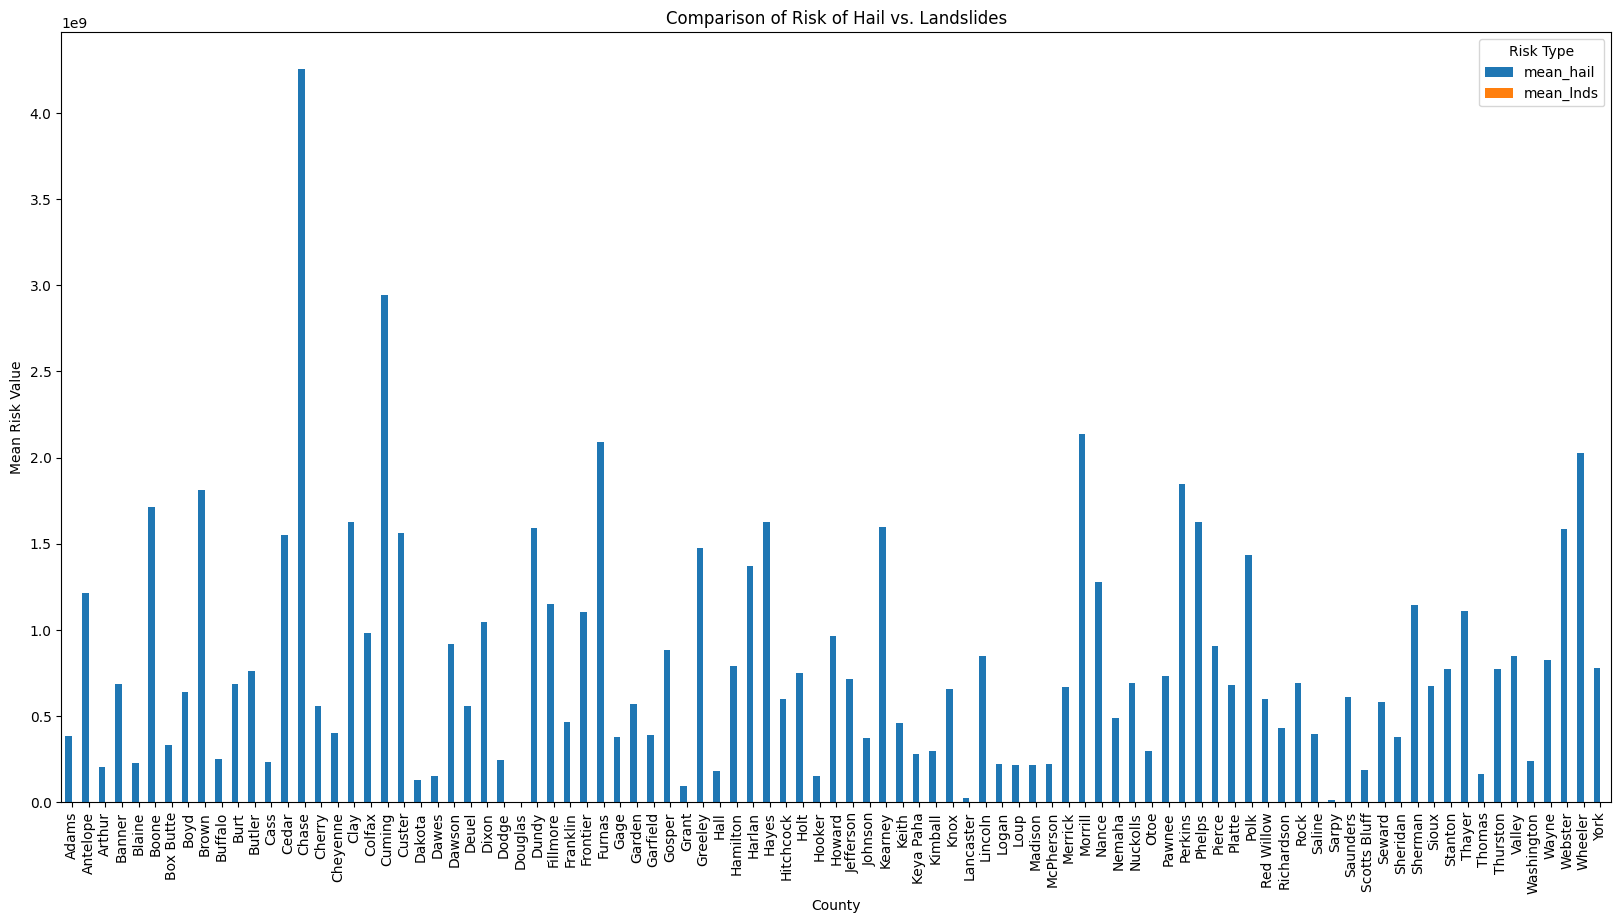

In [16]:
# Create bar plot with side-by-side bars (dodged effect)
grouped_data.plot(kind='bar', figsize=(20, 10), width=0.8)

# Customizing the plot
plt.xlabel('County')
plt.ylabel('Mean Risk Value')
plt.title('Comparison of Risk of Hail vs. Landslides')
plt.xticks(rotation=90)

# Show the plot
plt.legend(title="Risk Type")  # Adding a legend to distinguish risk types
plt.show()

In [30]:
grouped_data2 = complete_data.groupby('COUNTY').agg(mean_loss_per_fire=('loss_per_fire', 'mean'), 
                                                    mean_building_risk=('fire_building_risk', 'mean'))
print(grouped_data2)

            mean_loss_per_fire  mean_building_risk
COUNTY                                            
Adams             1.564450e+07        2.062306e+04
Alamosa           1.214072e+08        4.315767e+04
Arapahoe          1.789684e+07        1.689076e+04
Archuleta         1.383001e+08        1.465177e+06
Baca              3.848715e+07        3.491634e+05
...                        ...                 ...
Summit            3.776082e+07        3.735078e+04
Teller            1.105361e+08        4.146847e+06
Washington        5.424510e+07        1.038744e+05
Weld              1.615691e+07        4.853933e+04
Yuma              8.490196e+07        1.984061e+05

[64 rows x 2 columns]


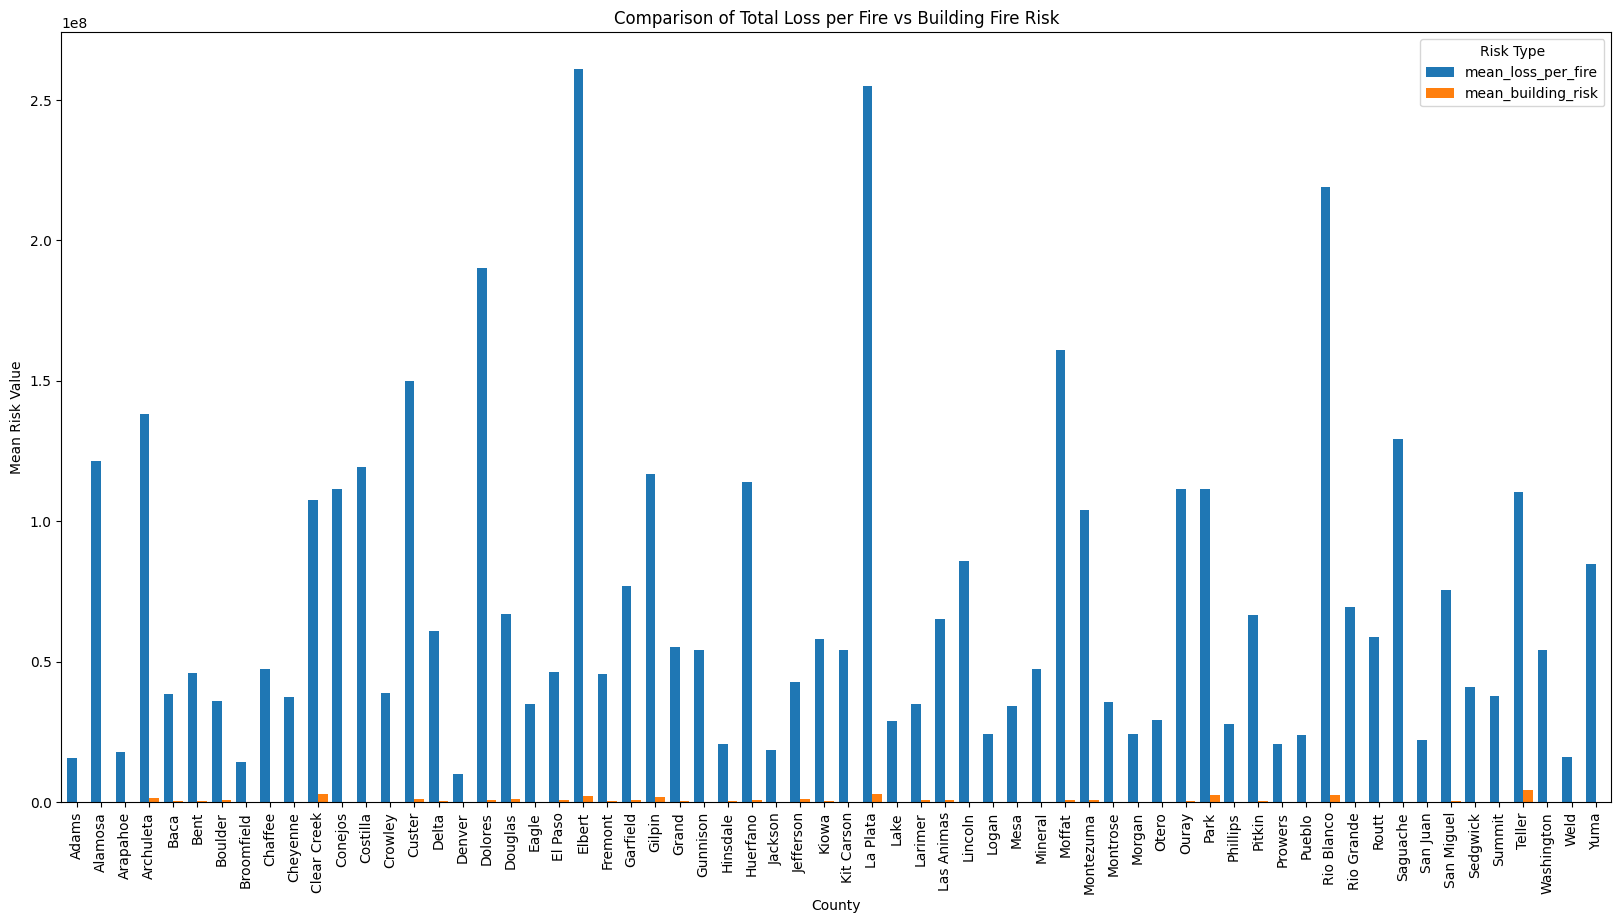

In [31]:
# Create bar plot with side-by-side bars (dodged effect)
grouped_data2.plot(kind='bar', figsize=(20, 10), width=0.8)

# Customizing the plot
plt.xlabel('County')
plt.ylabel('Mean Risk Value')
plt.title('Comparison of Total Loss per Fire vs Building Fire Risk')
plt.xticks(rotation=90)

# Show the plot
plt.legend(title="Risk Type")  # Adding a legend to distinguish risk types
plt.show()